<a href="https://colab.research.google.com/github/Muhammad-Bilal-Arshad/toyama-buddy/blob/main/toyama_buddy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗻 Toyama Buddy
**A weather-aware AI travel guide for foreign visitors to Toyama**




## 1. Setup

In [ ]:
!pip install -q -U google-genai chromadb sentence-transformers gradio requests

In [ ]:
from google.colab import userdata
from google import genai
from google.genai import types
import time, datetime

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

# Pick a real, currently available Flash model automatically (no guessing names)
available = [m.name for m in client.models.list()]
candidates = [n for n in available
              if 'flash' in n and not any(x in n for x in ['image', 'tts', 'live', 'audio', 'embedding', 'thinking-exp'])]
print("Flash models available:", candidates)

# The automatic pick is the LAST item in the list above.
# To choose a different one, replace the line below with, e.g., MODEL_NAME = "models/xxxx"
# MODEL_NAME = candidates[-1] if candidates else available[0]
# print("Using:", MODEL_NAME)
MODEL_NAME = "models/gemini-3.5-flash-lite"
print("Using:", MODEL_NAME)

def with_retry(fn, tries=4):
    """Retry when the free tier returns a rate-limit or overload error."""
    for i in range(tries):
        try:
            return fn()
        except Exception as e:
            msg = str(e)
            if any(c in msg for c in ['429', '503', 'RESOURCE_EXHAUSTED', 'UNAVAILABLE']) and i < tries - 1:
                wait = 10 * (i + 1)
                print(f"  (rate limited, retrying in {wait}s...)")
                time.sleep(wait)
            else:
                raise

r = with_retry(lambda: client.models.generate_content(model=MODEL_NAME, contents="Say hello in one sentence."))
print(r.text)

Flash models available: ['models/gemini-2.5-flash', 'models/gemini-flash-latest', 'models/gemini-flash-lite-latest', 'models/gemini-2.5-flash-lite', 'models/gemini-3-flash-preview', 'models/gemini-3.1-flash-lite-preview', 'models/gemini-3.1-flash-lite', 'models/gemini-3.5-flash', 'models/gemini-3.5-flash-lite', 'models/gemini-omni-flash-preview', 'models/gemini-omni-1.1-flash', 'models/gemini-3.6-flash', 'models/gemini-3.7-flash', 'models/gemini-3.8-flash']
Using: models/gemini-3.5-flash-lite
Hello, it's wonderful to meet you!


## 2. Knowledge base (RAG data)
Short summaries of Toyama tourism information.


In [ ]:
documents = [
 {"id": "alpine_route", "source": "https://www.alpen-route.com/en/",
  "text": """Tateyama Kurobe Alpine Route: a mountain sightseeing route crossing the Northern Japan Alps between Toyama and Nagano.
It is usually open from mid-April to the end of November and is closed in winter. In spring (roughly April to June) the famous
Snow Corridor at Murodo has walls of snow that can be over 15 meters high. Visitors travel by cable car, highland bus, trolley bus
and ropeway. Highlights include Murodo, Mikurigaike pond and Kurobe Dam. The Toyama side starts at Tateyama Station, reached by the
Toyama Chiho Railway from Dentetsu-Toyama (about one hour). It is at high altitude, so it is much colder than the city.
Strong wind, heavy rain or snow can stop services or ruin the views, so check the weather before going. Bring warm clothes."""},
 {"id": "glass_museum", "source": "https://toyama-glass-art-museum.jp/",
  "text": """Toyama Glass Art Museum: located inside the TOYAMA Kirari building in central Toyama City, designed by architect Kengo Kuma.
It shows contemporary glass art, including the Glass Art Garden with works by Dale Chihuly. It is fully indoors, making it one of the
best rainy-day activities in Toyama. It is a short walk or tram ride from Toyama Station. The same building contains the city library.
It is closed on some Wednesdays and at New Year, so check the official calendar."""},
 {"id": "tad_museum", "source": "https://tad-toyama.jp/",
  "text": """Toyama Prefectural Museum of Art and Design (TAD): a modern art and design museum next to Fugan Canal Kansui Park, about
a 15-minute walk from Toyama Station. It has art and design collections, and a free rooftop with playful objects and a view of the
Tateyama mountain range on clear days. The galleries are indoors, so it is a good option in bad weather."""},
 {"id": "kansui_park", "source": "https://foreign.info-toyama.com/en/",
  "text": """Fugan Canal Kansui Park: a waterside park near Toyama Station with the Tenmon-kyo bridge and a Starbucks often called one of
the most beautiful in the world. It is lit up at night and is popular in cherry blossom season. It is outdoors, so it is best
in good weather. A canal cruise operates in the warmer season."""},
 {"id": "toyama_castle", "source": "https://foreign.info-toyama.com/en/",
  "text": """Toyama Castle Park: a park in central Toyama City, about a 10-minute walk from Toyama Station. The castle keep is a
reconstruction that houses the Toyama Municipal Folk Museum of local history. The park itself is outdoors and pleasant for a
walk in good weather, especially in cherry blossom season."""},
 {"id": "food", "source": "https://foreign.info-toyama.com/en/",
  "text": """Toyama food: Toyama Bay is called a natural fish tank because of its fresh seafood. Famous dishes include shiroebi
(white shrimp, the 'jewel of Toyama Bay'), hotaru-ika (firefly squid, in season in spring), kan-buri (winter yellowtail from Himi),
masu-zushi (pressed trout sushi wrapped in bamboo leaves, a popular souvenir), and Toyama Black ramen with a very dark soy sauce soup.
Good places to try seafood include restaurants around Toyama Station and the Himi fishing port area. Many sushi restaurants offer
set menus, which are easy to order for visitors who don't read Japanese."""},
 {"id": "access", "source": "https://www.jrhokuriku.co.jp/global/en/",
  "text": """Getting to Toyama: the Hokuriku Shinkansen connects Tokyo Station and Toyama Station in about 2 hours 10 minutes on the
fastest trains (Kagayaki). The Japan Rail Pass and the Hokuriku Arch Pass can be used on this line. From Osaka or Kyoto, take the
Thunderbird limited express to Tsuruga, then the Hokuriku Shinkansen to Toyama. Toyama Kitokito Airport has domestic flights,
including from Tokyo Haneda. Seat reservations are recommended during Golden Week, Obon and New Year."""},
 {"id": "local_transport", "source": "https://www.chitetsu.co.jp/?lang=en",
  "text": """Getting around Toyama City: the Toyama tram (run by Toyama Chiho Railway) connects Toyama Station with the city center,
and the line to Iwasehama goes north to the old port town of Iwase. The trams stop right at Toyama Station. IC cards such as Suica
can be used on many lines, but check before boarding. The Toyama Chiho Railway trains from Dentetsu-Toyama Station go to Tateyama
(for the Alpine Route) and Unazuki Onsen (for Kurobe Gorge). Buses go to Gokayama and Shirakawa-go."""},
 {"id": "gokayama", "source": "https://gokayama-info.jp/en/",
  "text": """Gokayama: a UNESCO World Heritage area in Nanto City, Toyama, with traditional gassho-zukuri thatched-roof farmhouses in the
Ainokura and Suganuma villages. It is quieter than the nearby Shirakawa-go in Gifu. It can be reached by World Heritage bus from
Takaoka or Shin-Takaoka Station. Some farmhouses offer overnight stays. Snowy winter views are famous, but roads and buses can be
affected by heavy snow."""},
 {"id": "kurobe_gorge", "source": "https://www.kurotetu.co.jp/en/",
  "text": """Kurobe Gorge Railway: an open-air trolley train that runs through a deep mountain gorge from Unazuki Onsen. It usually
operates from spring to late November and is closed in winter. Parts of the line and operations have been affected by earthquake
damage and repair work in recent years, so always check the official operating status before visiting. It is an outdoor activity,
best in good weather, and very popular in autumn for the red and yellow leaves."""},
 {"id": "coast_himi", "source": "https://foreign.info-toyama.com/en/",
  "text": """Amaharashi Coast (Takaoka) and Himi: on clear days you can see the 3,000-meter Tateyama mountains rising across Toyama Bay,
one of the most famous views in Japan. The view is best on cold, clear mornings in winter and needs good weather. Himi, nearby, is
famous for its fishing port and winter yellowtail (kan-buri), and has a seaside market area. Takaoka has a large bronze Great Buddha
and the Zuiryuji Temple, a National Treasure."""},
 {"id": "hotaruika_museum", "source": "https://hotaruikamuseum.com/",
  "text": """Hotaruika Museum (Namerikawa): a museum about firefly squid, which glow blue. In the spring season (around March to May)
visitors can see a live light show of the squid. It is indoors. Early-morning sightseeing boats to watch the squid being caught
run in spring and depend on sea and weather conditions."""},
 {"id": "events", "source": "https://foreign.info-toyama.com/en/",
  "text": """Seasonal events in Toyama: Owara Kaze-no-Bon in Yatsuo (September 1 to 3) is a beautiful, quiet dance festival with
music of the kokyu and shamisen; it may be cancelled or shortened in rain. Spring brings cherry blossoms along the Matsukawa river
and the Snow Corridor on the Alpine Route. Summer is good for hiking in the Tateyama area. Autumn has colorful leaves in Kurobe Gorge.
Winter is the season for kan-buri yellowtail and snowy Gokayama."""},
 {"id": "rainy_day", "source": "https://foreign.info-toyama.com/en/",
  "text": """Rainy day ideas in Toyama City: Toyama Glass Art Museum (TOYAMA Kirari), Toyama Prefectural Museum of Art and Design (TAD),
the Toyama Municipal Folk Museum inside Toyama Castle, the Kobaien / Ikeda-yasubei shop to learn about Toyama's traditional
medicine-peddler history, shopping and food at the Toyama Station building (MARIER), and the Hotaruika Museum in Namerikawa."""},
]
print(f"Loaded {len(documents)} documents")

Loaded 14 documents


## 3. Build the vector database

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('intfloat/multilingual-e5-small')  # supports both English and Japanese

chroma = chromadb.Client()
try:
    chroma.delete_collection("toyama_kb")
except Exception:
    pass
collection = chroma.create_collection(name="toyama_kb", metadata={"hnsw:space": "cosine"})

# e5 models expect the prefix "passage: " on documents and "query: " on queries
collection.add(
    ids=[d["id"] for d in documents],
    embeddings=embedder.encode(["passage: " + d["text"] for d in documents]).tolist(),
    documents=[d["text"] for d in documents],
    metadatas=[{"source": d["source"]} for d in documents],
)
print("Indexed:", collection.count(), "documents")

def retrieve(query, top_k=3):
    q = embedder.encode(["query: " + query]).tolist()
    res = collection.query(query_embeddings=q, n_results=top_k)
    return list(zip(res["documents"][0], res["metadatas"][0], res["distances"][0]))

# Test retrieval on its own
test_questions = [
    "What is the Tateyama Kurobe Alpine Route and when is it open?",
    "What food is Toyama famous for?",
    "How do I get to Toyama from Tokyo?",
    "What is the Toyama Glass Art Museum?",
    "What can I do in Toyama if it's raining?",
    "富山の名物料理は何ですか？",
]
for q in test_questions:
    top = retrieve(q, top_k=1)[0]
    print(f"Q: {q}\n   -> best match: {top[1]['source']} (distance {top[2]:.3f})\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexed: 14 documents
Q: What is the Tateyama Kurobe Alpine Route and when is it open?
   -> best match: https://www.alpen-route.com/en/ (distance 0.082)

Q: What food is Toyama famous for?
   -> best match: https://foreign.info-toyama.com/en/ (distance 0.111)

Q: How do I get to Toyama from Tokyo?
   -> best match: https://www.jrhokuriku.co.jp/global/en/ (distance 0.106)

Q: What is the Toyama Glass Art Museum?
   -> best match: https://toyama-glass-art-museum.jp/ (distance 0.079)

Q: What can I do in Toyama if it's raining?
   -> best match: https://foreign.info-toyama.com/en/ (distance 0.136)

Q: 富山の名物料理は何ですか？
   -> best match: https://foreign.info-toyama.com/en/ (distance 0.240)



## 4. Agent tools
The SDK reads each function's docstring and type hints to tell Gemini what the tool does.


In [ ]:
import requests

TOOL_LOG = []

def search_knowledge_base(query: str) -> str:
    """Search the official Toyama tourism knowledge base for facts about attractions, food,
    transport, events, opening seasons and indoor/rainy-day activities.

    Args:
        query: the topic or question to search for, e.g. "rainy day activities"

    Returns:
        Relevant passages from the knowledge base, each with its source URL.
    """
    print(f"   🔧 TOOL CALL: search_knowledge_base(query={query!r})")
    TOOL_LOG.append(("search_knowledge_base", query))
    hits = retrieve(query, top_k=3)
    return "\n\n".join(f"{doc}\n(Source: {meta['source']})" for doc, meta, _ in hits)

WEATHER_CODES = {0: "clear sky", 1: "mainly clear", 2: "partly cloudy", 3: "overcast", 45: "fog", 48: "fog",
    51: "light drizzle", 53: "drizzle", 55: "heavy drizzle", 61: "light rain", 63: "rain", 65: "heavy rain",
    71: "light snow", 73: "snow", 75: "heavy snow", 77: "snow grains", 80: "rain showers", 81: "rain showers",
    82: "violent rain showers", 85: "snow showers", 86: "heavy snow showers", 95: "thunderstorm",
    96: "thunderstorm with hail", 99: "thunderstorm with hail"}

LOCATIONS = {"toyama city": (36.6953, 137.2113), "alpine route murodo": (36.5774, 137.5959)}

def get_weather(location: str = "toyama city") -> str:
    """Get the live 3-day weather forecast (today, tomorrow, day after) in Toyama.
    ALWAYS call this before recommending any outdoor activity.

    Args:
        location: either "toyama city" or "alpine route murodo" (the high mountain area,
                  use this for the Alpine Route)

    Returns:
        The daily forecast with weather description, rain amount and temperatures.
    """
    print(f"   🔧 TOOL CALL: get_weather(location={location!r})")
    TOOL_LOG.append(("get_weather", location))
    lat, lon = LOCATIONS.get(location.lower().strip(), LOCATIONS["toyama city"])
    params = {"latitude": lat, "longitude": lon, "timezone": "Asia/Tokyo", "forecast_days": 3,
              "daily": "weathercode,precipitation_sum,precipitation_probability_max,temperature_2m_max,temperature_2m_min,wind_speed_10m_max"}
    try:
        d = requests.get("https://api.open-meteo.com/v1/forecast", params=params, timeout=15).json()["daily"]
    except Exception as e:
        return f"Weather service unavailable: {e}"
    lines = []
    for i, date in enumerate(d["time"]):
        lines.append(f"{date}: {WEATHER_CODES.get(d['weathercode'][i], 'code ' + str(d['weathercode'][i]))}, "
                     f"rain {d['precipitation_sum'][i]} mm (chance {d['precipitation_probability_max'][i]}%), "
                     f"{d['temperature_2m_min'][i]}-{d['temperature_2m_max'][i]}°C, max wind {d['wind_speed_10m_max'][i]} km/h")
    return f"Forecast for {location}:\n" + "\n".join(lines)

# Quick test of both tools
print(get_weather("alpine route murodo"))
print(search_knowledge_base("rainy day")[:300])

   🔧 TOOL CALL: get_weather(location='alpine route murodo')
Forecast for alpine route murodo:
2026-09-17: partly cloudy, rain 0.0 mm (chance 92%), 6.6-11.5°C, max wind 7.9 km/h
2026-09-18: drizzle, rain 0.6 mm (chance 100%), 6.9-13.2°C, max wind 6.1 km/h
2026-09-19: light rain, rain 5.9 mm (chance 94%), 8.1-12.4°C, max wind 7.5 km/h
   🔧 TOOL CALL: search_knowledge_base(query='rainy day')
Rainy day ideas in Toyama City: Toyama Glass Art Museum (TOYAMA Kirari), Toyama Prefectural Museum of Art and Design (TAD),
the Toyama Municipal Folk Museum inside Toyama Castle, the Kobaien / Ikeda-yasubei shop to learn about Toyama's traditional
medicine-peddler history, shopping and food at the T


## 5. The agent

In [ ]:
today = datetime.datetime.now(datetime.timezone(datetime.timedelta(hours=9))).strftime("%Y-%m-%d (%A)")

SYSTEM_PROMPT = f"""You are Toyama Buddy, a friendly local travel guide for foreign visitors to Toyama, Japan.
Today's date in Japan is {today}.

Rules:
1. For any factual question about Toyama, call search_knowledge_base first. Base your answer on the results and
   end with a short "Sources:" line listing the source URLs you used.
2. Before recommending any OUTDOOR activity (Alpine Route, Toyama Castle Park, Kansui Park, Kurobe Gorge,
   Amaharashi Coast, hiking), call get_weather. For the Alpine Route, use location "alpine route murodo".
3. If the weather is bad (rain, snow, thunderstorm, strong wind, or rain chance above 60%), do NOT recommend the
   outdoor plan. Say why, and suggest indoor alternatives found with search_knowledge_base.
4. If an attraction is out of season (for example, the Alpine Route in winter), say so clearly.
5. If the information is not in the knowledge base, say you're not sure and suggest checking the official site.
   Never invent prices or opening hours.
6. Reply in the same language the user writes in.
7. Be concise, warm and practical, like a helpful local friend. Use short paragraphs or a simple timeline for plans."""

agent_config = types.GenerateContentConfig(
    system_instruction=SYSTEM_PROMPT,
    tools=[search_knowledge_base, get_weather],   # Python functions -> automatic function calling
    temperature=0.3,
)

def ask_agent(message, chat=None):
    """Send one message to the agent. Pass the same chat object back in to keep the conversation going."""
    if chat is None:
        chat = client.chats.create(model=MODEL_NAME, config=agent_config)
    resp = with_retry(lambda: chat.send_message(message))
    return (resp.text or "(no text returned)"), chat

# ⭐ KEY DEMO: the agent should check the mountain weather and adapt its plan
print("USER: I want to see the Alpine Route tomorrow. What should I do?\n")
answer, chat = ask_agent("I want to see the Alpine Route tomorrow. What should I do?")
print("\nTOYAMA BUDDY:\n" + answer)

USER: I want to see the Alpine Route tomorrow. What should I do?

   🔧 TOOL CALL: get_weather(location='alpine route murodo')
   🔧 TOOL CALL: search_knowledge_base(query='Alpine Route rainy day alternative indoor activities Toyama')

TOYAMA BUDDY:
Hi there! I'd love to help you plan your trip, but I just checked the weather forecast for Murodo (on the Alpine Route) for tomorrow, and it's calling for a 100% chance of rain with drizzle. 

Because the Alpine Route is all about high-altitude mountain views and outdoor transport (like ropeways, buses, and walking trails), heavy clouds and rain mean visibility will likely be very poor, and you won't get to see those amazing mountain panoramas. 

Instead, how about checking out some fantastic indoor spots right here in Toyama City tomorrow to stay nice and dry? Here are a few great alternatives:

*   **Toyama Glass Art Museum (TOYAMA Kirari):** Housed in a stunning building designed by Kengo Kuma, it features breathtaking contemporary glass a

In [ ]:
# Follow-up in the same conversation (shows that the agent remembers context)
answer, chat = ask_agent("OK, and where should I eat dinner near the station after that?", chat)
print("\nTOYAMA BUDDY:\n" + answer)

   🔧 TOOL CALL: search_knowledge_base(query='Toyama Station restaurants food dinner sushi black ramen')

TOYAMA BUDDY:
For dinner right near Toyama Station, you are in for a real treat! Toyama Bay is famous for its incredible seafood—often called a "natural fish tank." 

Here are two great local specialties you should try just steps from the station:

1. **Toyama Bay Sushi:** If you love fresh seafood, look for a sushi restaurant offering *Toyama-wan Sushi* (Toyama Bay sushi sets). You'll get a gorgeous platter of ultra-fresh local fish, often including *shiroebi* (white shrimp, known as the "jewel of Toyama Bay"). There are several great sushi spots right inside and around Toyama Station (such as in the station's dining areas like MARIER or the local market arcades).
2. **Toyama Black Ramen:** If it's a bit chilly and rainy, warm up with a bowl of Toyama Black ramen. It's famous for its very dark, rich soy sauce-based broth and topped with plenty of black pepper and tender pork. It's 

In [ ]:
# A Japanese question, to show multilingual support
answer, _ = ask_agent("雨の日に富山市でおすすめの場所は？")
print("\nTOYAMA BUDDY:\n" + answer)

   🔧 TOOL CALL: search_knowledge_base(query='rainy day activities toyama city indoor')

TOYAMA BUDDY:
雨の日でも富山市内で楽しく過ごせるおすすめのスポットをいくつかご紹介しますね！すべて屋内でゆっくり楽しめる場所ばかりです。

1. **富山市ガラス美術館（TOYAMAキラリ）**
   * **特徴**: 建築家の隈研吾氏がデザインした複合施設「TOYAMAキラリ」の中にあります。美しいガラスアートや、世界的アーティストであるデイル・チフーリ氏の「グラス・アート・ガーデン」などが鑑賞できます。建物自体が木の温もりを感じるアートな空間なので、雨の日でも気分が上がりますよ！富山駅から路面電車（市内電車）でアクセスできます。

2. **富山県美術館（TAD）**
   * **特徴**: 富岩運河環水公園のすぐ近くにある、モダンな美術館です。ピカソやミロなどの巨匠の作品から、国内外の優れたポスターや椅子などのデザイン作品まで幅広く展示されています。ガラス張りの館内からは運河の景色も楽しめます。

3. **池田屋安兵衛商店（和漢薬の街・富山を体験）**
   * **特徴**: 富山の伝統的な「置き薬」の文化に触れられるお店です。昔ながらの丸薬づくり体験ができたり、レトロな店内を覗くだけでも楽しめます。2階には薬膳料理が食べられるお店もあり、雨の日に温かい料理でほっと一息つくのにおすすめです。

4. **富山駅周辺（MARIERなどの商業施設やグルメ）**
   * **特徴**: 雨の日なら、富山駅直結や周辺のショッピングエリアで富山のグルメ（白エビ、ホタルイカ、寿司など）を堪能したり、お土産探しをするのも便利です。

雨の日は移動に気をつけて、素敵な富山のひとときをお過ごしくださいね！

Sources:
- https://foreign.info-toyama.com/en/
- https://toyama-glass-art-museum.jp/
- https://tad-toyama.jp/


## 6. Evaluation: plain LLM vs. Toyama Buddy
The same questions are sent to (a) Gemini with no RAG and no tools, and (b) the full agent.
The results are saved to `evaluation.md`, which you can put in your slides and GitHub repo.

In [ ]:
import re

eval_questions = [
    "What is the Tateyama Kurobe Alpine Route and when is it open?",
    "What food is Toyama famous for?",
    "How long does it take from Tokyo to Toyama by train?",
    "What can I do in Toyama City if it's raining today?",
    "Should I go to the Amaharashi Coast tomorrow?",
    "What is today's weather in Toyama?",
]

rows = []
for q in eval_questions:
    print("Q:", q)
    base = with_retry(lambda: client.models.generate_content(model=MODEL_NAME, contents=q)).text or ""
    TOOL_LOG.clear()
    agent_ans, _ = ask_agent(q)
    tools_used = sorted({t for t, _ in TOOL_LOG})
    rows.append({
        "q": q,
        "base": base,
        "agent": agent_ans,
        "tools": ", ".join(tools_used) or "none",
        "base_cites": bool(re.search(r"https?://", base)),
        "agent_cites": bool(re.search(r"https?://", agent_ans)),
    })
    time.sleep(3)  # be gentle with free-tier rate limits

with open("evaluation.md", "w") as f:
    f.write("# Evaluation: plain Gemini vs. Toyama Buddy\n\n")
    f.write("| Question | Tools used by agent | Plain LLM cites source | Agent cites source |\n|---|---|---|---|\n")
    for r in rows:
        f.write(f"| {r['q']} | {r['tools']} | {'✅' if r['base_cites'] else '❌'} | {'✅' if r['agent_cites'] else '❌'} |\n")
    for r in rows:
        f.write(f"\n## {r['q']}\n\n**Plain LLM:**\n\n{r['base']}\n\n**Toyama Buddy (tools: {r['tools']}):**\n\n{r['agent']}\n")

agent_tool_rate = sum(r["tools"] != "none" for r in rows) / len(rows)
print(f"\nAgent used tools on {agent_tool_rate:.0%} of questions")
print(f"Source citation rate: plain LLM {sum(r['base_cites'] for r in rows)}/{len(rows)}, "
      f"agent {sum(r['agent_cites'] for r in rows)}/{len(rows)}")
print("Saved evaluation.md  (download it from the 📁 Files panel on the left)")

Q: What is the Tateyama Kurobe Alpine Route and when is it open?
   🔧 TOOL CALL: search_knowledge_base(query='Tateyama Kurobe Alpine Route open dates operating season')
Q: What food is Toyama famous for?
   🔧 TOOL CALL: search_knowledge_base(query='Toyama famous food specialty gourmet sushi firefly squid shrimp yellowtail')
  (rate limited, retrying in 10s...)
   🔧 TOOL CALL: search_knowledge_base(query='famous food gourmet specialties Toyama prefecture')
Q: How long does it take from Tokyo to Toyama by train?
   🔧 TOOL CALL: search_knowledge_base(query='Tokyo to Toyama train time Hokuriku Shinkansen')
Q: What can I do in Toyama City if it's raining today?
   🔧 TOOL CALL: get_weather(location='toyama city')
   🔧 TOOL CALL: search_knowledge_base(query='rainy day activities Toyama City indoor attractions museums art glass')
Q: Should I go to the Amaharashi Coast tomorrow?
   🔧 TOOL CALL: get_weather(location='toyama city')
   🔧 TOOL CALL: search_knowledge_base(query='Amaharashi Coast')
Q

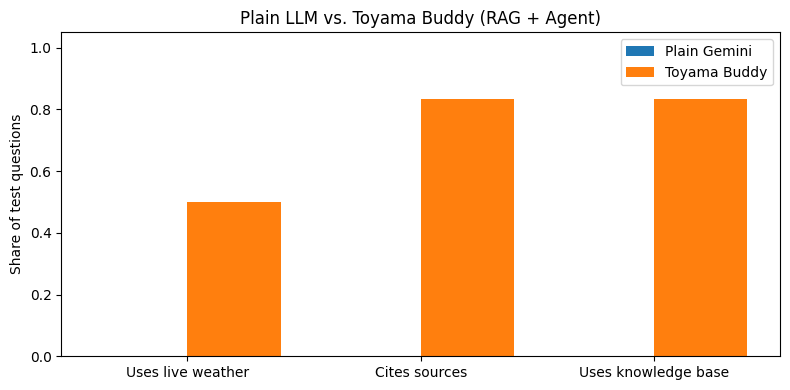

In [ ]:
# Chart for your slides
import matplotlib.pyplot as plt
labels = ["Uses live weather", "Cites sources", "Uses knowledge base"]
plain = [0, sum(r["base_cites"] for r in rows) / len(rows), 0]
agent = [sum("get_weather" in r["tools"] for r in rows) / len(rows),
         sum(r["agent_cites"] for r in rows) / len(rows),
         sum("search_knowledge_base" in r["tools"] for r in rows) / len(rows)]
x = range(len(labels))
plt.figure(figsize=(8, 4))
plt.bar([i - 0.2 for i in x], plain, width=0.4, label="Plain Gemini")
plt.bar([i + 0.2 for i in x], agent, width=0.4, label="Toyama Buddy")
plt.xticks(list(x), labels); plt.ylim(0, 1.05); plt.ylabel("Share of test questions")
plt.title("Plain LLM vs. Toyama Buddy (RAG + Agent)"); plt.legend(); plt.tight_layout()
plt.savefig("evaluation_chart.png", dpi=150); plt.show()

## 7. Demo UI (Gradio)
Running this cell gives you a public `gradio.live` link.

In [ ]:
import gradio as gr

def to_text(content):
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return " ".join(c.get("text", "") if isinstance(c, dict) else str(c) for c in content)
    if isinstance(content, dict):
        return content.get("text", "")
    return str(content)

def respond(message, history):
    past = []
    for h in history:
        role, text = h.get("role"), to_text(h.get("content"))
        if role in ("user", "assistant") and text:
            past.append(types.Content(role="user" if role == "user" else "model",
                                      parts=[types.Part(text=text)]))
    chat = client.chats.create(model=MODEL_NAME, config=agent_config, history=past)
    TOOL_LOG.clear()
    answer, _ = ask_agent(to_text(message), chat)
    if TOOL_LOG:
        used = "\n".join(f"- `{t}`({a!r})" for t, a in TOOL_LOG)
        answer += f"\n\n---\n🔧 *Agent actions:*\n{used}"
    return answer

examples = [
    "I want to see the Alpine Route tomorrow. What should I do?",
    "It's raining, what can I do in Toyama City?",
    "What food should I try in Toyama?",
    "How do I get from Tokyo to Toyama?",
    "富山でおすすめの観光地は？",
]
kwargs = dict(fn=respond, title="🗻 Toyama Buddy",
              description="Your weather-aware AI travel guide for Toyama. Ask in any language!",
              examples=examples)
try:
    demo = gr.ChatInterface(type="messages", **kwargs)
except TypeError:           # newer Gradio versions have no 'type' argument
    demo = gr.ChatInterface(**kwargs)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1707a5c1787d523d04.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
